In [69]:
import torch

from src import model as models

## importamos los dataloaders
from src.datadogs import dog_train_loader, dog_test_loader

from src.utils import probar_modelo, comparar_modelos

from src.train import train_ae, train_metanca


In [39]:
# Configuración de hardware acelerado
device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f"Usando el dispositivo: {device}")

## para que los cambios en los files se apliquen sin reiniciar kernels
%load_ext autoreload
%autoreload 2

Usando el dispositivo: cuda
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
## parametros para probar entrenamiento autoencoder

params_encoder1 = {
    'in_c': 3,
    # --- ENCODER ---
    'Conv2DParams1': {'out_c': 64, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
                      'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1},
    'Conv2DParams2': {'out_c': 128, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                      'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1},
    
    # Pass-through debe terminar con 128 canales y stride total de 2 para sumar con Conv2DParams2
    'PassThroughParams1': {'out_c': 64, 'kernel_size': 1, 'strides': 1, 'padding': 0, 
                           'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    'PassThroughParams2': {'out_c': 128, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                           'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    
    'Conv2DParams3': {'out_c': 256, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                      'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.2},

    # --- DECODER ---
    'Conv2DTransposeParams3': {'out_c': 128, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                               'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    'Conv2DTransposeParams2': {'out_c': 64, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                               'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    
    # MixParams recibe d2_out (64) + c1_out (64), mantiene 64 canales
    'MixParams': {'out_c': 64, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
                  'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    
    # Salida final: 3 canales para las 3 clases del dataset
    'Conv2DTransposeParams1': {'out_c': 3, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
                               'activation': None, 'batch_normalization': False, 'dropout_rate': 0.0}
}

In [71]:
params_encoder2 = {
    'in_c': 3,
    
    # ==================== ENCODER ====================
    # Conv1 define el canal de nuestro 'skip_out' de alta resolución. 
    # Bajamos a 32 canales para balancear la carga computacional.
    'Conv2DParams1': {
        'out_c': 32, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1
    },
    
    # Conv2 comprime el espacio (/2) y sube canales. Terminamos con 64 canales.
    'Conv2DParams2': {
        'out_c': 64, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1
    },
    
    # Camino Pass-through: Debe igualar exactamente la salida de Conv2DParams2 (64 canales y stride total de 2)
    'PassThroughParams1': {
        'out_c': 32, 'kernel_size': 1, 'strides': 1, 'padding': 0, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0
    },
    'PassThroughParams2': {
        'out_c': 64, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0
    },
    
    # Capa final del Encoder (Conv3): Aquí colapsamos la información al espacio latente objetivo.
    'Conv2DParams3': {
        'out_c': 16, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1
    },

    # ==================== DECODER ====================
    # TransConv3 procesa el latente del NCA (16 canales) y recupera la resolución espacial (*2).
    # Lo subimos a 64 canales para ir preparando el terreno de la mezcla.
    'Conv2DTransposeParams3': {
        'out_c': 64, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0
    },
    
    # TransConv2 recupera la resolución original (*2). 
    # CRÍTICO: Debe salir con 32 canales para coincidir con los 32 canales de 'Conv2DParams1' (skip_out).
    'Conv2DTransposeParams2': {
        'out_c': 32, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0
    },
    
    # MixParams recibe la suma directa de d2_out (32) + c1_out (32).
    # Procesa la combinación manteniendo 32 canales para refinar bordes antes de clasificar.
    'MixParams': {
        'out_c': 32, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0
    },
    
    # Salida final del Decoder: Proyecta los 32 canales a los 3 canales del trimapa (fondo, interior, borde)
    'Conv2DTransposeParams1': {
        'out_c': 3, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
        'activation': None, 'batch_normalization': False, 'dropout_rate': 0.0
    }
}

##con estos parametros el espacio se colapsa a 1/4 de la resolución original, con 16 canales en el latente para los nca

In [76]:
ae_model = models.AutoEncoderDown3(params_encoder2).to(device)

In [86]:
train_ae(ae_model, dog_train_loader, epochs=5, device=device)

torch.save(ae_model.state_dict(), "ae_model_og.pth")

Iniciando Fase 1 directamente en el Autoencoder por 5 épocas...
Época [1/5 - Loss promedio: 1.2770)]
Época [2/5 - Loss promedio: 1.2641)]
Época [3/5 - Loss promedio: 1.2531)]
Época [4/5 - Loss promedio: 1.2414)]
Época [5/5 - Loss promedio: 1.2376)]


Loss en el batch de prueba: 1.2751


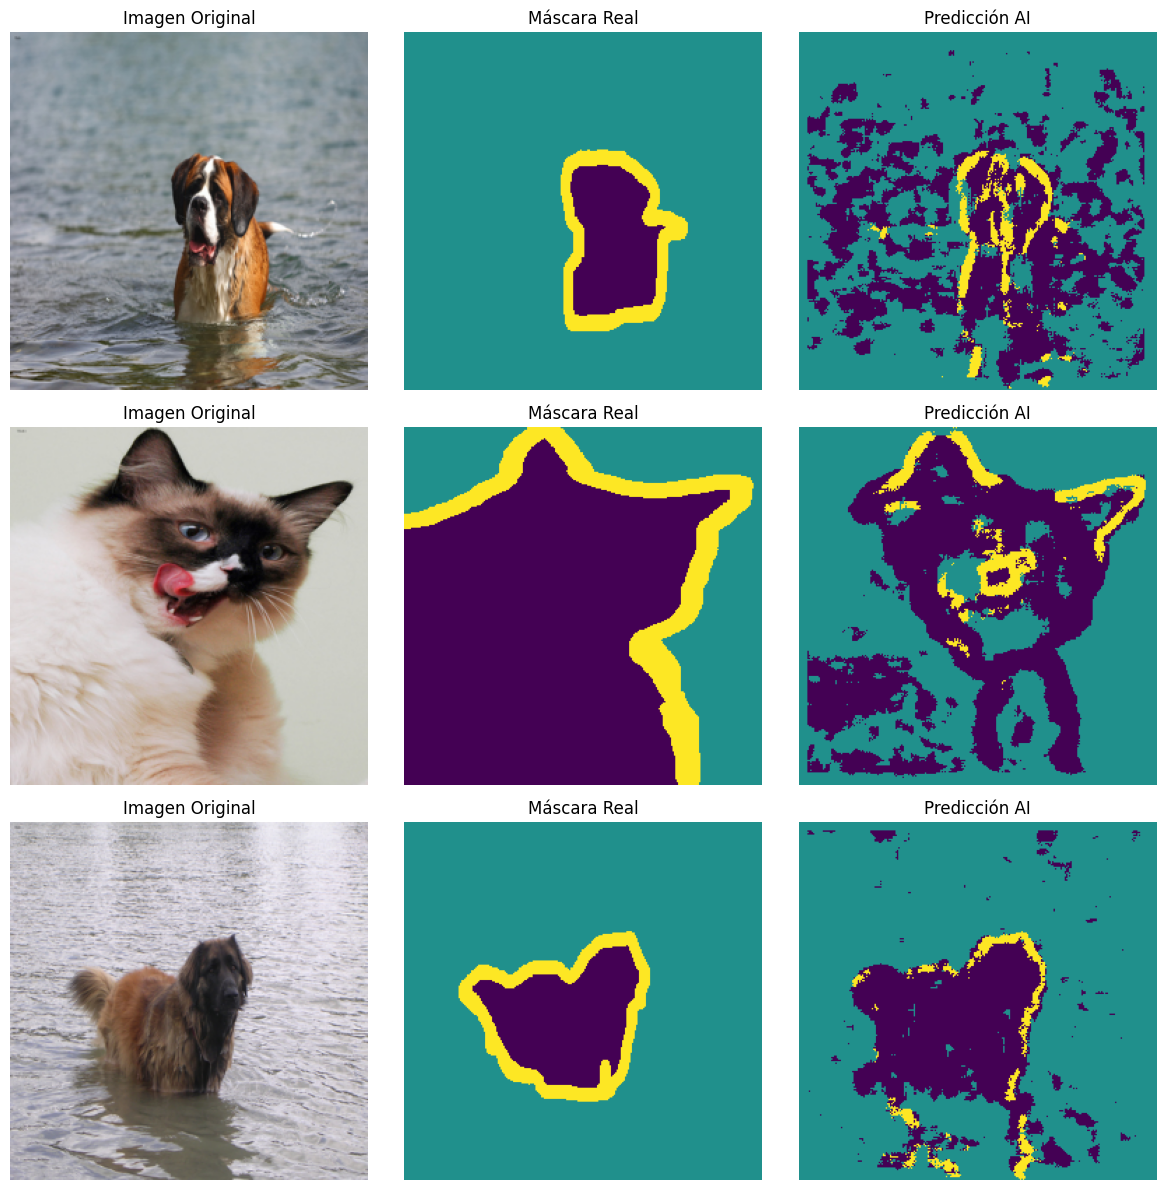

In [92]:
probar_modelo(ae_model, dog_test_loader, device)

In [98]:
meta_nca = models.MetaNCASegmenter(ae_params=params_encoder2, nca_steps=16).to(device)


In [99]:
meta_nca.ae.load_state_dict(torch.load("ae_model_og.pth", map_location=device))

<All keys matched successfully>

In [100]:
train_metanca(meta_nca, dog_train_loader, epochs=5, device=device)

 Congelando parámetros del Autoencoder...
 Iniciando loop de prueba preliminar blindado...

✅ Van 10 batches procesados exitosamente.
📊 Loss promedio actual: 1.1895
💧 Leak Factor actual: 0.0922

✅ Van 20 batches procesados exitosamente.
📊 Loss promedio actual: 1.1930
💧 Leak Factor actual: 0.0885

✅ Van 30 batches procesados exitosamente.
📊 Loss promedio actual: 1.1837
💧 Leak Factor actual: 0.0861

✅ Van 40 batches procesados exitosamente.
📊 Loss promedio actual: 1.1825
💧 Leak Factor actual: 0.0838

✅ Van 50 batches procesados exitosamente.
📊 Loss promedio actual: 1.2083
💧 Leak Factor actual: 0.0792

✅ Van 60 batches procesados exitosamente.
📊 Loss promedio actual: 1.2076
💧 Leak Factor actual: 0.0782

✅ Van 70 batches procesados exitosamente.
📊 Loss promedio actual: 1.2131
💧 Leak Factor actual: 0.0787

✅ Van 80 batches procesados exitosamente.
📊 Loss promedio actual: 1.2253
💧 Leak Factor actual: 0.0779

✅ Van 90 batches procesados exitosamente.
📊 Loss promedio actual: 1.2343
💧 Leak Fact

In [103]:
meta_nca.nca_steps = 32

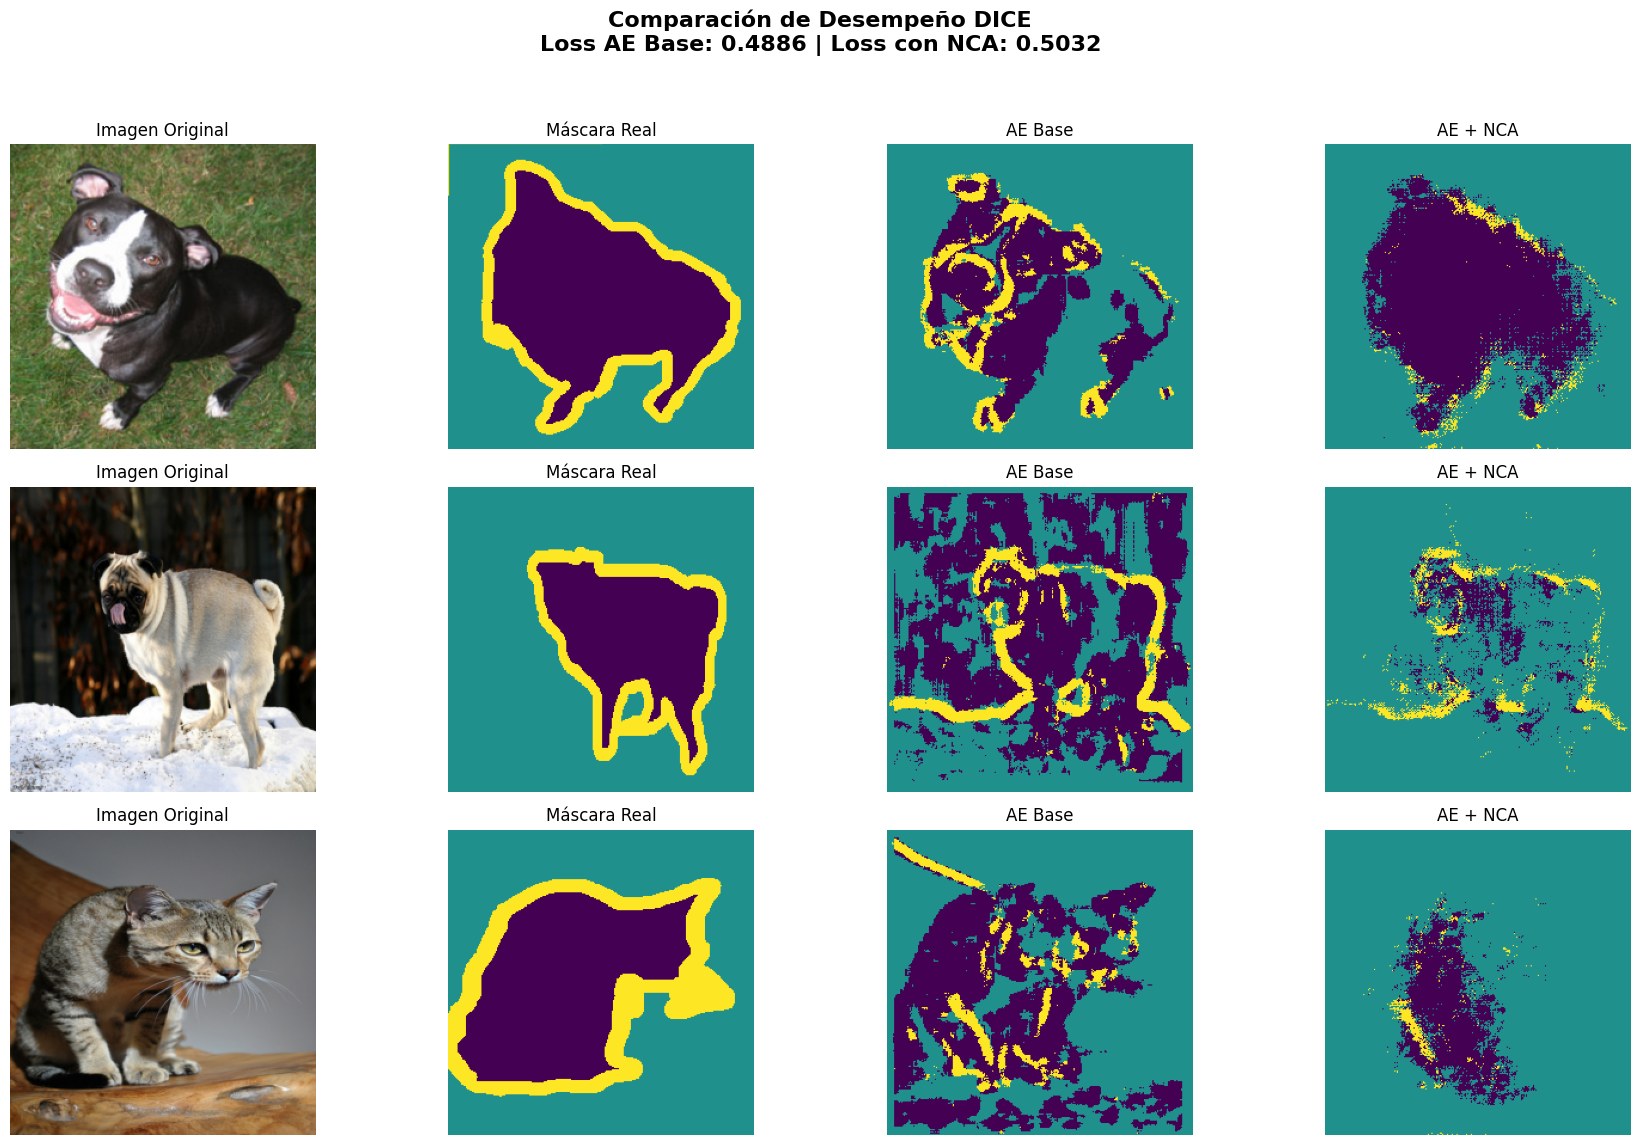

In [105]:
comparar_modelos(ae_model, meta_nca, dog_test_loader, device)

In [106]:
torch.save(meta_nca.state_dict(), "metanca_model_og.pth")